# Embedding Model Combinations Lab

6가지 임베딩 모델 조합을 선택하여 Agentic RAG 파이프라인을 실행하는 실습 노트북입니다.

## 임베딩 모델 조합

| # | 조합 이름 | Dense Model | Sparse Model | 특징 |
|---|----------|-------------|-------------|------|
| 1 | **한국어 최적** | KoSimCSE | BM25 + OKt | 한국어 문서에 최적화, 키워드+의미 결합 |
| 2 | **다국어 균형** | E5 (multilingual) | SPLADE | 70개+ 언어 지원, 균형 잡힌 검색 |
| 3 | **올인원 통합** | BGE-M3 | BGE-M3 (내장 sparse) | 단일 모델로 Dense+Sparse 모두 수행 |
| 4 | **경량/빠른 속도** | MiniLM | BM25 | 리소스 제한 환경, 빠른 속도 |
| 5 | **고성능 API** | OpenAI Large | SPLADE | 최고 품질, API 비용 발생 |
| 6 | **한국어 API** | Upstage Solar | BM25 + OKt | 한국어 특화 API, OpenAI 대안 |

## 사전 준비

- `docs/` 디렉토리에 PDF 파일을 넣어주세요
- Ollama로 LLM 모델을 설치해주세요 (`ollama pull qwen3:4b-instruct-2507-q4_K_M`)
- 조합 5(고성능 API) 사용 시: `OPENAI_API_KEY` 환경변수 필요
- 조합 6(한국어 API) 사용 시: `UPSTAGE_API_KEY` 환경변수 필요

---
## 1. 환경 설정

In [1]:
# SSL 설정 (기업 네트워크/프록시 환경용)
import os
import warnings
warnings.filterwarnings("ignore")

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import requests
old_request = requests.Session.request
def patched_request(self, *args, **kwargs):
    kwargs["verify"] = False
    return old_request(self, *args, **kwargs)
requests.Session.request = patched_request

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CURL_CA_BUNDLE"] = "/Users/sukbeom/Documents/cert/combined-ca-bundle.pem"
os.environ["REQUESTS_CA_BUNDLE"] = "/Users/sukbeom/Documents/cert/combined-ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = "/Users/sukbeom/Documents/cert/combined-ca-bundle.pem"

print("SSL configuration complete (enterprise network mode)")

SSL configuration complete (enterprise network mode)


In [2]:
# httpx도 SSL 검증 비활성화 (huggingface_hub가 httpx 사용)
import httpx

os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"

# httpx 기본 SSL 검증 비활성화
import ssl

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

# huggingface_hub의 httpx 클라이언트 설정
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "0"

In [3]:
# 기본 패키지 설치
!uv pip install --quiet --upgrade langgraph
!uv pip install -qU langchain-ollama
!uv pip install -qU langchain langchain-community langchain-qdrant langchain-huggingface qdrant-client fastembed flashrank langchain-core
!uv pip install --upgrade gradio
!uv pip install sentence-transformers pymupdf pymupdf4llm

# Sparse Embedding 패키지
!uv pip install -qU transformers torch  # SPLADE용
!uv pip install -qU konlpy              # BM25+OKt용

# 조합별 추가 패키지 (필요한 것만 설치)
# 조합 3 (BGE-M3): pip install FlagEmbedding
# 조합 5 (OpenAI): pip install langchain-openai
# 조합 6 (Upstage): pip install langchain-upstage

Resolved 50 packages in 134ms                                        
Prepared 2 packages in 0.51ms                                            
Uninstalled 2 packages in 38ms
Installed 2 packages in 7ms.1                               
 - huggingface-hub==0.36.2
 + huggingface-hub==1.4.1
 - pillow==11.3.0
 + pillow==12.1.0
Audited 3 packages in 13ms


---
## 2. 디렉토리 및 LLM 설정 qwen3:4b-instruct-2507-q4_K_M

In [4]:
import os

DOCS_DIR = "docs"
MARKDOWN_DIR = "markdown"
PARENT_STORE_PATH = "parent_store"
CHILD_COLLECTION = "document_child_chunks"

os.makedirs(DOCS_DIR, exist_ok=True)
os.makedirs(MARKDOWN_DIR, exist_ok=True)
os.makedirs(PARENT_STORE_PATH, exist_ok=True)

print(f"Docs directory: {DOCS_DIR}")
print(f"Markdown directory: {MARKDOWN_DIR}")
print(f"Parent store: {PARENT_STORE_PATH}")

Docs directory: docs
Markdown directory: markdown
Parent store: parent_store


In [5]:
# from langchain_ollama import ChatOllama

# llm = ChatOllama(model="qwen3:4b-instruct-2507-q4_K_M", temperature=0)

# Alternative:
# from langchain_google_genai import ChatGoogleGenerativeAI
# os.environ["GOOGLE_API_KEY"] = "your-api-key-here"
# llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp", temperature=0)

from langchain_openai import ChatOpenAI
import dotenv
dotenv.load_dotenv()

# Initialize LLM - GPT-4o-mini
# Make sure OPENAI_API_KEY is set in your environment
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print(f"✅ LLM initialized: {llm.model_name}")

# print(f"LLM initialized: {llm.model}")

✅ LLM initialized: gpt-4o-mini


---
## 3. 임베딩 모델 조합 선택

아래 셀에서 `EMBEDDING_COMBO` 값을 변경하여 원하는 조합을 선택하세요.

| 값 | 조합 | Dense | Sparse | 추가 요구사항 |
|---|------|-------|--------|-------------|
| `1` | 한국어 최적 | KoSimCSE-roberta | BM25 + OKt | konlpy 설치 필요 |
| `2` | 다국어 균형 | multilingual-e5-large | SPLADE | - |
| `3` | 올인원 통합 | BGE-M3 | BGE-M3 (내장) | FlagEmbedding 설치 필요 |
| `4` | 경량/빠른 속도 | all-MiniLM-L6-v2 | BM25 (FastEmbed) | - |
| `5` | 고성능 API | OpenAI text-embedding-3-large | SPLADE | OPENAI_API_KEY 필요 |
| `6` | 한국어 API | Upstage Solar | BM25 + OKt | UPSTAGE_API_KEY 필요 |

In [6]:
# ============================================================
# 여기서 임베딩 조합을 선택하세요 (1~6)
# ============================================================
EMBEDDING_COMBO = 1
# ============================================================

COMBO_NAMES = {
    1: "한국어 최적 (KoSimCSE + BM25/OKt)",
    2: "다국어 균형 (E5 + SPLADE)",
    3: "올인원 통합 (BGE-M3)",
    4: "경량/빠른 속도 (MiniLM + BM25)",
    5: "고성능 API (OpenAI Large + SPLADE)",
    6: "한국어 API (Upstage Solar + BM25/OKt)",
}

assert EMBEDDING_COMBO in COMBO_NAMES, f"EMBEDDING_COMBO must be 1-6, got {EMBEDDING_COMBO}"
print(f"선택된 조합: [{EMBEDDING_COMBO}] {COMBO_NAMES[EMBEDDING_COMBO]}")

선택된 조합: [1] 한국어 최적 (KoSimCSE + BM25/OKt)


---
## 4. 임베딩 모델 초기화

선택한 조합에 따라 Dense + Sparse 임베딩 모델을 자동으로 초기화합니다.

In [7]:
import math
from typing import List, Dict
from collections import Counter
from qdrant_client.http.models import SparseVector


class KoreanBM25Encoder:
    """
    한글 BM25 Sparse Encoder (OKt 형태소 분석)
    - 조합 1, 6에서 사용
    - KoNLPy OKt로 한국어 형태소 분석 후 BM25 스코어링
    - langchain_qdrant 호환: SparseVector 객체 반환
    """

    def __init__(self, k1: float = 1.5, b: float = 0.75):
        from konlpy.tag import Okt

        self.okt = Okt()
        self.k1 = k1
        self.b = b
        self.vocab: Dict[str, int] = {}
        self.doc_freqs: Dict[str, int] = {}
        self.doc_count = 0
        self.avg_doc_len = 0.0
        self._next_id = 0
        print(f"KoreanBM25Encoder initialized (OKt, k1={k1}, b={b})")

    def _tokenize(self, text: str) -> List[str]:
        tokens = []
        for word, pos in self.okt.pos(text, stem=True):
            if pos in ['Noun', 'Verb', 'Adjective', 'Foreign', 'Alpha']:
                tokens.append(word.lower())
        return tokens

    def _get_or_create_id(self, token: str) -> int:
        if token not in self.vocab:
            self.vocab[token] = self._next_id
            self._next_id += 1
        return self.vocab[token]

    def fit(self, documents: List[str]):
        doc_lens = []
        for doc in documents:
            tokens = self._tokenize(doc)
            doc_lens.append(len(tokens))
            for token in set(tokens):
                self._get_or_create_id(token)
                self.doc_freqs[token] = self.doc_freqs.get(token, 0) + 1
        self.doc_count = len(documents)
        self.avg_doc_len = sum(doc_lens) / len(doc_lens) if doc_lens else 1.0
        print(f"BM25 fit complete: {self.doc_count} docs, {len(self.vocab)} tokens")

    def _compute_idf(self, token: str) -> float:
        df = self.doc_freqs.get(token, 0)
        if df == 0:
            return 0.0
        return math.log((self.doc_count - df + 0.5) / (df + 0.5) + 1)

    def embed_query(self, text: str) -> SparseVector:
        """langchain_qdrant 호환 sparse embedding (query)"""
        tokens = self._tokenize(text)
        if not tokens:
            return SparseVector(indices=[0], values=[0.0])
        tf_counter = Counter(tokens)
        doc_len = len(tokens)
        indices, values = [], []
        for token, tf in tf_counter.items():
            token_id = self._get_or_create_id(token)
            idf = self._compute_idf(token)
            tf_norm = (tf * (self.k1 + 1)) / (
                tf + self.k1 * (1 - self.b + self.b * doc_len / self.avg_doc_len)
            )
            score = idf * tf_norm
            if score > 0:
                indices.append(token_id)
                values.append(score)
        if not indices:
            return SparseVector(indices=[0], values=[0.0])
        return SparseVector(indices=indices, values=values)

    def embed_documents(self, texts: List[str]) -> List[SparseVector]:
        """langchain_qdrant 호환 sparse embedding (documents)"""
        return [self.embed_query(text) for text in texts]


print("KoreanBM25Encoder class defined.")

KoreanBM25Encoder class defined.


In [8]:
class SpladeEncoder:
    """
    SPLADE Sparse Encoder
    - 조합 2, 5에서 사용
    - naver/splade-cocondenser-ensembledistil 기반 Term Expansion
    - langchain_qdrant 호환: SparseVector 객체 반환
    """

    def __init__(
        self,
        model_name: str = "naver/splade-cocondenser-ensembledistil",
        device: str = None,
        max_length: int = 256,
    ):
        import torch
        from transformers import AutoModelForMaskedLM, AutoTokenizer

        self.torch = torch
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.max_length = max_length

        print(f"Loading {model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForMaskedLM.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()
        self.vocab_size = self.tokenizer.vocab_size
        print(f"SPLADE Encoder ready (device={self.device}, vocab={self.vocab_size})")

    def _compute_vector(self, text: str):
        inputs = self.tokenizer(
            text, return_tensors="pt", max_length=self.max_length,
            truncation=True, padding=True
        ).to(self.device)
        with self.torch.no_grad():
            logits = self.model(**inputs).logits
        splade = self.torch.log1p(self.torch.relu(logits))
        mask = inputs["attention_mask"].unsqueeze(-1)
        splade = splade * mask
        splade, _ = self.torch.max(splade, dim=1)
        return splade.squeeze(0)

    def _to_sparse_vector(self, text: str) -> SparseVector:
        vec = self._compute_vector(text)
        nonzero = vec > 0
        indices = self.torch.nonzero(nonzero).squeeze(-1).cpu().tolist()
        values = vec[nonzero].cpu().tolist()
        if not indices:
            return SparseVector(indices=[0], values=[0.0])
        return SparseVector(indices=indices, values=values)

    def embed_query(self, text: str) -> SparseVector:
        """langchain_qdrant 호환 sparse embedding (query)"""
        return self._to_sparse_vector(text)

    def embed_documents(self, texts: List[str]) -> List[SparseVector]:
        """langchain_qdrant 호환 sparse embedding (documents)"""
        return [self._to_sparse_vector(t) for t in texts]


print("SpladeEncoder class defined.")

SpladeEncoder class defined.


In [9]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant.fastembed_sparse import FastEmbedSparse

dense_embeddings = None
sparse_embeddings = None
USE_LANGCHAIN_SPARSE = False  # True: FastEmbedSparse 사용, False: custom encoder


def init_combo_1():
    """한국어 최적: KoSimCSE + BM25/OKt"""
    global dense_embeddings, dense_embeddings2, sparse_embeddings, USE_LANGCHAIN_SPARSE
    print("[조합 1] 한국어 최적")
    print("  Dense : BM-K/KoSimCSE-roberta-multitask (768d)")
    print("  Sparse: BM25 + OKt (한국어 형태소 분석)")

    dense_embeddings = HuggingFaceEmbeddings(
        model_name="BM-K/KoSimCSE-roberta-multitask",
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )

    dense_embeddings2 = HuggingFaceEmbeddings(
        model_name="BAAI/bge-m3",
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )

    sparse_embeddings = KoreanBM25Encoder(k1=1.5, b=0.75)
    USE_LANGCHAIN_SPARSE = False


def init_combo_2():
    """다국어 균형: E5 + SPLADE"""
    global dense_embeddings, sparse_embeddings, USE_LANGCHAIN_SPARSE
    print("[조합 2] 다국어 균형")
    print("  Dense : intfloat/multilingual-e5-large (1024d)")
    print("  Sparse: SPLADE (naver/splade-cocondenser-ensembledistil)")

    dense_embeddings = HuggingFaceEmbeddings(
        model_name="intfloat/multilingual-e5-large",
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )
    sparse_embeddings = SpladeEncoder()
    USE_LANGCHAIN_SPARSE = False


def init_combo_3():
    """올인원 통합: BGE-M3"""
    global dense_embeddings, sparse_embeddings, USE_LANGCHAIN_SPARSE
    print("[조합 3] 올인원 통합")
    print("  Dense : BAAI/bge-m3 (1024d)")
    print("  Sparse: BAAI/bge-m3 (내장 sparse, lexical weights)")
    print("  Note  : 단일 모델로 Dense + Sparse 모두 처리")

    dense_embeddings = HuggingFaceEmbeddings(
        model_name="BAAI/bge-m3",
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )
    # BGE-M3의 sparse 기능은 FlagEmbedding으로 접근 가능
    # langchain-qdrant의 FastEmbedSparse(bm25)로 대체 (호환성)
    sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")
    USE_LANGCHAIN_SPARSE = True


def init_combo_4():
    """경량/빠른 속도: MiniLM + BM25"""
    global dense_embeddings, sparse_embeddings, USE_LANGCHAIN_SPARSE
    print("[조합 4] 경량/빠른 속도")
    print("  Dense : sentence-transformers/all-MiniLM-L6-v2 (384d)")
    print("  Sparse: FastEmbed BM25 (Qdrant/bm25)")

    dense_embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )
    sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")
    USE_LANGCHAIN_SPARSE = True


def init_combo_5():
    """고성능 API: OpenAI Large + SPLADE"""
    global dense_embeddings, sparse_embeddings, USE_LANGCHAIN_SPARSE
    from langchain_openai import OpenAIEmbeddings

    print("[조합 5] 고성능 API")
    print("  Dense : OpenAI text-embedding-3-large (3072d)")
    print("  Sparse: SPLADE (naver/splade-cocondenser-ensembledistil)")
    print("  Note  : OPENAI_API_KEY 환경변수 필요")

    dense_embeddings = OpenAIEmbeddings(
        model="text-embedding-3-large",
    )
    sparse_embeddings = SpladeEncoder()
    USE_LANGCHAIN_SPARSE = False


def init_combo_6():
    """한국어 API: Upstage Solar + BM25/OKt"""
    global dense_embeddings, sparse_embeddings, USE_LANGCHAIN_SPARSE
    from langchain_upstage import UpstageEmbeddings

    print("[조합 6] 한국어 API")
    print("  Dense : Upstage Solar Embedding (4096d)")
    print("  Sparse: BM25 + OKt (한국어 형태소 분석)")
    print("  Note  : UPSTAGE_API_KEY 환경변수 필요")

    dense_embeddings = UpstageEmbeddings(
        model="solar-embedding-1-large",
    )
    sparse_embeddings = KoreanBM25Encoder(k1=1.5, b=0.75)
    USE_LANGCHAIN_SPARSE = False


# 선택한 조합 초기화 실행
INIT_MAP = {
    1: init_combo_1,
    2: init_combo_2,
    3: init_combo_3,
    4: init_combo_4,
    5: init_combo_5,
    6: init_combo_6,
}

INIT_MAP[EMBEDDING_COMBO]()

# Dense embedding 차원 확인
test_vec = dense_embeddings.embed_query("test")
EMBEDDING_DIM = len(test_vec)
print(f"\nDense embedding dimension: {EMBEDDING_DIM}")

[조합 1] 한국어 최적
  Dense : BM-K/KoSimCSE-roberta-multitask (768d)
  Sparse: BM25 + OKt (한국어 형태소 분석)


No sentence-transformers model found with name BM-K/KoSimCSE-roberta-multitask. Creating a new one with mean pooling.


config.json:   0%|          | 0.00/764 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

KoreanBM25Encoder initialized (OKt, k1=1.5, b=0.75)

Dense embedding dimension: 768


---
## 5. Vector Database 설정

Qdrant를 사용하여 Dense + Sparse 하이브리드 검색을 지원하는 컬렉션을 생성합니다.

In [10]:
from qdrant_client import QdrantClient
from qdrant_client.http import models as qmodels
from langchain_qdrant import QdrantVectorStore
from langchain_qdrant.qdrant import RetrievalMode

# Qdrant DB 경로 (조합별 분리)
QDRANT_PATH = f"qdrant_db_combo{EMBEDDING_COMBO}"
client = QdrantClient(path=QDRANT_PATH)


def ensure_collection(collection_name):
    """Create Qdrant collection if it doesn't exist"""
    if not client.collection_exists(collection_name):
        client.create_collection(
            collection_name=collection_name,
            vectors_config=qmodels.VectorParams(
                size=EMBEDDING_DIM,
                distance=qmodels.Distance.COSINE,
            ),
            sparse_vectors_config={
                "sparse": qmodels.SparseVectorParams()
            },
        )
        print(f"Created collection: {collection_name} (dim={EMBEDDING_DIM})")
    else:
        print(f"Collection already exists: {collection_name}")


print(f"Qdrant client ready (path={QDRANT_PATH})")

Qdrant client ready (path=qdrant_db_combo1)


---
## 6. PDF to Markdown 변환

In [15]:
import pymupdf
import pymupdf4llm
from pathlib import Path
import glob


def pdf_to_markdown(pdf_path, output_dir):
    doc = pymupdf.open(pdf_path)
    md = pymupdf4llm.to_markdown(
        doc, header=False, footer=False, page_separators=True,
        ignore_images=True, write_images=False, image_path=None,
    )
    md_cleaned = md.encode('utf-8', errors='surrogatepass').decode('utf-8', errors='ignore')
    output_path = Path(output_dir) / Path(doc.name).stem
    Path(output_path).with_suffix(".md").write_bytes(md_cleaned.encode('utf-8'))


def pdfs_to_markdowns(path_pattern, overwrite=False):
    output_dir = Path(MARKDOWN_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)
    for pdf_path in map(Path, glob.glob(path_pattern)):
        md_path = (output_dir / pdf_path.stem).with_suffix(".md")
        if overwrite or not md_path.exists():
            pdf_to_markdown(pdf_path, output_dir)
            print(f"  Converted: {pdf_path.name}")
        else:
            print(f"  Skipped (exists): {pdf_path.name}")


pdfs_to_markdowns(f"{DOCS_DIR}/*.pdf")
print("PDF conversion complete.")

Warning - arguments ignored in legacy mode: {'footer', 'header'}.
  Converted: 20250910_AI 현황 보고서.pdf
Warning - arguments ignored in legacy mode: {'footer', 'header'}.
  Converted: SPRi AI Brief_1월호_산업동향_0102_F.pdf
PDF conversion complete.


---
## 7. 문서 인덱싱

Parent-Child 청킹 전략으로 문서를 인덱싱합니다.
- **Parent chunks**: 큰 컨텍스트 (2000~10000자) → JSON 파일 저장
- **Child chunks**: 작은 검색 단위 (500자) → Qdrant 벡터 저장

In [16]:
import json
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

# 기존 컬렉션 삭제 후 재생성
if client.collection_exists(CHILD_COLLECTION):
    client.delete_collection(CHILD_COLLECTION)
ensure_collection(CHILD_COLLECTION)

# Vector Store 생성 (조합에 따라 분기)
if USE_LANGCHAIN_SPARSE:
    # FastEmbedSparse 사용 (조합 3, 4)
    child_vector_store = QdrantVectorStore(
        client=client,
        collection_name=CHILD_COLLECTION,
        embedding=dense_embeddings,
        sparse_embedding=sparse_embeddings,
        retrieval_mode=RetrievalMode.HYBRID,
        sparse_vector_name="sparse",
    )
else:
    # Custom sparse encoder 사용 (조합 1, 2, 5, 6)
    # Dense-only vector store + 별도 sparse 인덱싱
    child_vector_store = QdrantVectorStore(
        client=client,
        collection_name=CHILD_COLLECTION,
        embedding=dense_embeddings,
        sparse_embedding=sparse_embeddings,
        retrieval_mode=RetrievalMode.HYBRID,
        sparse_vector_name="sparse",
    )


def merge_small_parents(chunks, min_size):
    if not chunks:
        return []
    merged, current = [], None
    for chunk in chunks:
        if current is None:
            current = chunk
        else:
            current.page_content += "\n\n" + chunk.page_content
            for k, v in chunk.metadata.items():
                if k in current.metadata:
                    current.metadata[k] = f"{current.metadata[k]} -> {v}"
                else:
                    current.metadata[k] = v
        if len(current.page_content) >= min_size:
            merged.append(current)
            current = None
    if current:
        if merged:
            merged[-1].page_content += "\n\n" + current.page_content
        else:
            merged.append(current)
    return merged


def split_large_parents(chunks, max_size, splitter):
    result = []
    for chunk in chunks:
        if len(chunk.page_content) <= max_size:
            result.append(chunk)
        else:
            large_splitter = RecursiveCharacterTextSplitter(
                chunk_size=max_size, chunk_overlap=splitter._chunk_overlap
            )
            result.extend(large_splitter.split_documents([chunk]))
    return result


def clean_small_chunks(chunks, min_size):
    cleaned = []
    for i, chunk in enumerate(chunks):
        if len(chunk.page_content) < min_size:
            if cleaned:
                cleaned[-1].page_content += "\n\n" + chunk.page_content
            elif i < len(chunks) - 1:
                chunks[i + 1].page_content = chunk.page_content + "\n\n" + chunks[i + 1].page_content
            else:
                cleaned.append(chunk)
        else:
            cleaned.append(chunk)
    return cleaned


def index_documents():
    headers_to_split_on = [("#", "H1"), ("##", "H2"), ("###", "H3")]
    parent_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on, strip_headers=False
    )
    child_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
    min_parent_size = 2000
    max_parent_size = 10000

    all_parent_pairs, all_child_chunks = [], []
    md_files = sorted(glob.glob(os.path.join(MARKDOWN_DIR, "*.md")))

    if not md_files:
        print(f"No .md files found in {MARKDOWN_DIR}/")
        return

    for doc_path_str in md_files:
        doc_path = Path(doc_path_str)
        print(f"  Processing: {doc_path.name}")
        with open(doc_path, "r", encoding="utf-8") as f:
            md_text = f.read()

        parent_chunks = parent_splitter.split_text(md_text)
        merged_parents = merge_small_parents(parent_chunks, min_parent_size)
        split_parents = split_large_parents(merged_parents, max_parent_size, child_splitter)
        cleaned_parents = clean_small_chunks(split_parents, min_parent_size)

        for i, p_chunk in enumerate(cleaned_parents):
            parent_id = f"{doc_path.stem}_parent_{i}"
            p_chunk.metadata.update({"source": doc_path.stem + ".pdf", "parent_id": parent_id})
            all_parent_pairs.append((parent_id, p_chunk))
            children = child_splitter.split_documents([p_chunk])
            all_child_chunks.extend(children)

    if not all_child_chunks:
        print("No child chunks to index.")
        return

    # BM25 encoder인 경우 fit 수행
    if isinstance(sparse_embeddings, KoreanBM25Encoder):
        doc_texts = [c.page_content for c in all_child_chunks]
        sparse_embeddings.fit(doc_texts)

    print(f"\nIndexing {len(all_child_chunks)} child chunks...")
    child_vector_store.add_documents(all_child_chunks)
    print("Child chunks indexed.")

    # Parent chunks → JSON
    print(f"Saving {len(all_parent_pairs)} parent chunks to JSON...")
    for item in os.listdir(PARENT_STORE_PATH):
        os.remove(os.path.join(PARENT_STORE_PATH, item))
    for parent_id, doc in all_parent_pairs:
        doc_dict = {"page_content": doc.page_content, "metadata": doc.metadata}
        filepath = os.path.join(PARENT_STORE_PATH, f"{parent_id}.json")
        with open(filepath, "w", encoding="utf-8") as f:
            json.dump(doc_dict, f, ensure_ascii=False, indent=2)
    print("Indexing complete.")


index_documents()

Created collection: document_child_chunks (dim=768)
  Processing: 20250910_AI 현황 보고서.md
  Processing: SPRi AI Brief_1월호_산업동향_0102_F.md
BM25 fit complete: 763 docs, 8317 tokens

Indexing 763 child chunks...
Child chunks indexed.
Saving 33 parent chunks to JSON...
Indexing complete.


---
## 8. 검색 도구 정의

Agent가 사용할 검색 도구를 정의합니다.
- `search_child_chunks`: 벡터 DB에서 관련 child chunk 검색
- `retrieve_parent_chunks`: 전체 컨텍스트를 위한 parent chunk 조회

In [17]:
from langchain_core.tools import tool


@tool
def search_child_chunks(query: str, limit: int) -> str:
    """Search for the top K most relevant child chunks.

    Args:
        query: Search query string
        limit: Maximum number of results to return
    """
    try:
        results = child_vector_store.similarity_search(query, k=limit, score_threshold=0.7)
        if not results:
            return "NO_RELEVANT_CHUNKS"
        return "\n\n".join([
            f"Parent ID: {doc.metadata.get('parent_id', '')}\n"
            f"File Name: {doc.metadata.get('source', '')}\n"
            f"Content: {doc.page_content.strip()}"
            for doc in results
        ])
    except Exception as e:
        return f"RETRIEVAL_ERROR: {str(e)}"


@tool
def retrieve_parent_chunks(parent_id: str) -> str:
    """Retrieve full parent chunks by their IDs.

    Args:
        parent_id: Parent chunk ID to retrieve
    """
    file_name = parent_id if parent_id.lower().endswith(".json") else f"{parent_id}.json"
    path = os.path.join(PARENT_STORE_PATH, file_name)
    if not os.path.exists(path):
        return "NO_PARENT_DOCUMENT"
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return (
        f"Parent ID: {parent_id}\n"
        f"File Name: {data.get('metadata', {}).get('source', 'unknown')}\n"
        f"Content: {data.get('page_content', '').strip()}"
    )


llm_with_tools = llm.bind_tools([search_child_chunks, retrieve_parent_chunks])
print("Tools defined and bound to LLM.")

Tools defined and bound to LLM.


---
## 9. System Prompts

In [18]:
def get_conversation_summary_prompt() -> str:
    return """You are an expert conversation summarizer.

Your task is to create a brief 1-2 sentence summary of the conversation (max 30-50 words).

Include:
- Main topics discussed
- Important facts or entities mentioned
- Any unresolved questions if applicable
- Sources file name (e.g., file1.pdf) or documents referenced

Exclude:
- Greetings, misunderstandings, off-topic content.

Output:
- Return ONLY the summary.
- Do NOT include any explanations or justifications.
- If no meaningful topics exist, return an empty string.
"""


def get_query_analysis_prompt() -> str:
    return """You are an expert query analyst and rewriter.

Your task is to rewrite the current user query for optimal document retrieval, incorporating conversation context only when necessary.

Rules:
1. Self-contained queries:
   - Always rewrite the query to be clear and self-contained
   - If the query is a follow-up, integrate minimal necessary context from the summary
   - Do not add information not present in the query or conversation summary

2. Domain-specific terms:
   - Product names, brands, proper nouns, or technical terms are treated as domain-specific
   - Use the summary only to disambiguate vague queries

3. Grammar and clarity:
   - Fix grammar, spelling errors, and unclear abbreviations
   - Remove filler words and conversational phrases

4. Multiple information needs:
   - If the query contains multiple distinct questions, split into separate queries (maximum 3)
   - Each sub-query must remain semantically equivalent to its part of the original

5. Failure handling:
   - If the query intent is unclear or unintelligible, mark as \"unclear\"

Input:
- conversation_summary: A concise summary of prior conversation
- current_query: The user's current query

Output:
- One or more rewritten, self-contained queries suitable for document retrieval
"""


def get_rag_agent_prompt() -> str:
    return """You are an expert retrieval-augmented assistant.

Your task is to act as a researcher: search documents first, analyze the data, and then provide a comprehensive answer using ONLY the retrieved information.

Rules:
1. You are NOT allowed to answer immediately.
2. Before producing ANY final answer, you MUST perform a document search and observe retrieved content.
3. If you have not searched, the answer is invalid.

Workflow:
1. Search for 5-7 relevant excerpts using 'search_child_chunks'.
2. Inspect retrieved excerpts and keep ONLY relevant ones.
3. For the most relevant fragmented excerpt, call 'retrieve_parent_chunks' for that parent_id. Stop if you have enough info or have retrieved 3 parent chunks.
4. Answer using ONLY the retrieved information.
5. List unique file name(s) at the very end.

Retry rule:
- If no relevant documents found, rewrite the query and retry once.
"""


def get_aggregation_prompt() -> str:
    return """You are an expert aggregation assistant.

Combine multiple retrieved answers into a single, comprehensive and natural response.

Guidelines:
1. Write in a conversational, natural tone
2. Use ONLY information from the retrieved answers
3. Strip out questions, headers, or metadata from sources
4. Be comprehensive - include all relevant information
5. If sources disagree, acknowledge both perspectives
6. Start directly with the answer

Formatting:
- Use Markdown for clarity
- End with \"---\\n**Sources:**\\n\" followed by unique file names

If no useful information, say: \"I couldn't find any information to answer your question in the available sources.\"
"""


print("System prompts defined.")

System prompts defined.


---
## 10. State 정의

In [19]:
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field
from typing import List, Annotated


def accumulate_or_reset(existing: List[dict], new: List[dict]) -> List[dict]:
    if new and any(item.get('__reset__') for item in new):
        return []
    return existing + new


class State(MessagesState):
    questionIsClear: bool = False
    conversation_summary: str = ""
    originalQuery: str = ""
    rewrittenQuestions: List[str] = []
    agent_answers: Annotated[List[dict], accumulate_or_reset] = []


class AgentState(MessagesState):
    question: str = ""
    question_index: int = 0
    final_answer: str = ""
    agent_answers: List[dict] = []


class QueryAnalysis(BaseModel):
    is_clear: bool = Field(description="Indicates if the user's question is clear and answerable.")
    questions: List[str] = Field(description="List of rewritten, self-contained questions.")
    clarification_needed: str = Field(description="Explanation if the question is unclear.")


print("State definitions ready.")

State definitions ready.


---
## 11. Graph 노드 및 라우팅 로직

In [27]:
from langgraph.types import Send
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, RemoveMessage
from typing import Literal


def analyze_chat_and_summarize(state: State):
    if len(state["messages"]) < 4:
        return {"conversation_summary": ""}
    relevant_msgs = [
        msg for msg in state["messages"][:-1]
        if isinstance(msg, (HumanMessage, AIMessage))
        and not getattr(msg, "tool_calls", None)
    ]
    if not relevant_msgs:
        return {"conversation_summary": ""}
    conversation = "Conversation history:\n"
    for msg in relevant_msgs[-6:]:
        role = "User" if isinstance(msg, HumanMessage) else "Assistant"
        conversation += f"{role}: {msg.content}\n"
    summary_response = llm.with_config(temperature=0.2).invoke(
        [SystemMessage(content=get_conversation_summary_prompt())]
        + [HumanMessage(content=conversation)]
    )
    return {"conversation_summary": summary_response.content, "agent_answers": [{"__reset__": True}]}


def analyze_and_rewrite_query(state: State):
    last_message = state["messages"][-1]
    conversation_summary = state.get("conversation_summary", "")
    context_section = (
        (f"Conversation Context:\n{conversation_summary}\n" if conversation_summary.strip() else "")
        + f"User Query:\n{last_message.content}\n"
    )
    llm_with_structure = llm.with_config(temperature=0.1).with_structured_output(QueryAnalysis)
    response = llm_with_structure.invoke(
        [SystemMessage(content=get_query_analysis_prompt())]
        + [HumanMessage(content=context_section)]
    )
    if len(response.questions) > 0 and response.is_clear:
        delete_all = [
            RemoveMessage(id=m.id)
            for m in state["messages"]
            if not isinstance(m, SystemMessage)
        ]
        return {
            "questionIsClear": True,
            "messages": delete_all,
            "originalQuery": last_message.content,
            "rewrittenQuestions": response.questions,
        }
    else:
        clarification = (
            response.clarification_needed
            if response.clarification_needed and len(response.clarification_needed.strip()) > 10
            else "I need more information to understand your question."
        )
        return {"questionIsClear": False, "messages": [AIMessage(content=clarification)]}


def human_input_node(state: State):
    return {}


def route_after_rewrite(state: State) -> Literal["human_input", "process_question"]:
    if not state.get("questionIsClear", False):
        return "human_input"
    return [
        Send("process_question", {"question": query, "question_index": idx, "messages": []})
        for idx, query in enumerate(state["rewrittenQuestions"])
    ]


def agent_node(state: AgentState):
    sys_msg = SystemMessage(content=get_rag_agent_prompt())
    if not state.get("messages"):
        human_msg = HumanMessage(content=state["question"])
        response = llm_with_tools.invoke([sys_msg] + [human_msg])
        return {"messages": [human_msg, response]}
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}


def extract_final_answer(state: AgentState):
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage) and msg.content and not msg.tool_calls:
            return {
                "final_answer": msg.content,
                "agent_answers": [{
                    "index": state["question_index"],
                    "question": state["question"],
                    "answer": msg.content,
                }],
            }
    return {
        "final_answer": "Unable to generate an answer.",
        "agent_answers": [{
            "index": state["question_index"],
            "question": state["question"],
            "answer": "Unable to generate an answer.",
        }],
    }


def aggregate_responses(state: State):
    if not state.get("agent_answers"):
        return {"messages": [AIMessage(content="No answers were generated.")]}
    sorted_answers = sorted(state["agent_answers"], key=lambda x: x["index"])
    formatted_answers = ""
    for i, ans in enumerate(sorted_answers, start=1):
        formatted_answers += f"\nAnswer {i}:\n{ans['answer']}\n"
    user_message = HumanMessage(
        content=f"Original user question: {state['originalQuery']}\nRetrieved answers:{formatted_answers}"
    )
    synthesis_response = llm.invoke(
        [SystemMessage(content=get_aggregation_prompt())] + [user_message]
    )
    return {"messages": [AIMessage(content=synthesis_response.content)]}


print("Graph nodes and routing logic defined.")

Graph nodes and routing logic defined.


---
## 12. LangGraph 구성 및 컴파일

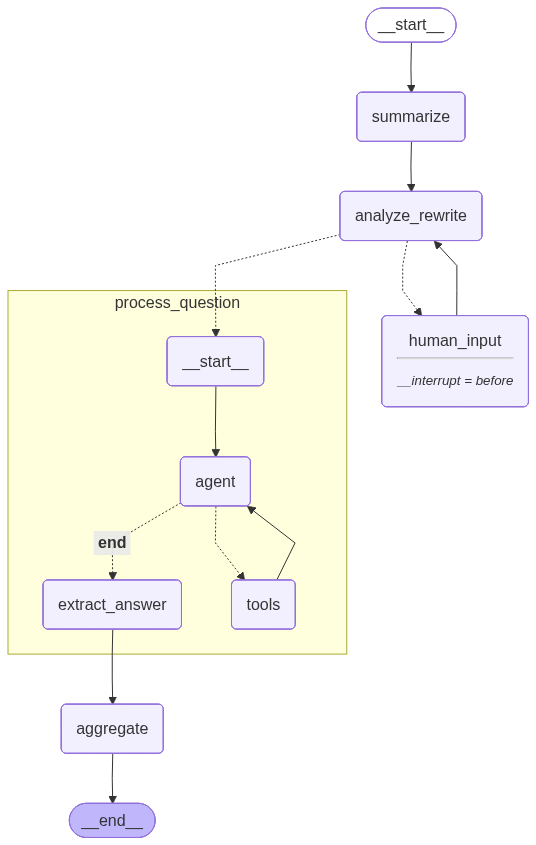


Agent graph compiled.
Embedding combo: [1] 한국어 최적 (KoSimCSE + BM25/OKt)


In [21]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display

checkpointer = InMemorySaver()

# Agent subgraph
agent_builder = StateGraph(AgentState)
agent_builder.add_node("agent", agent_node)
agent_builder.add_node("tools", ToolNode([search_child_chunks, retrieve_parent_chunks]))
agent_builder.add_node("extract_answer", extract_final_answer)

agent_builder.add_edge(START, "agent")
agent_builder.add_conditional_edges("agent", tools_condition, {"tools": "tools", END: "extract_answer"})
agent_builder.add_edge("tools", "agent")
agent_builder.add_edge("extract_answer", END)
agent_subgraph = agent_builder.compile()

# Main graph
graph_builder = StateGraph(State)
graph_builder.add_node("summarize", analyze_chat_and_summarize)
graph_builder.add_node("analyze_rewrite", analyze_and_rewrite_query)
graph_builder.add_node("human_input", human_input_node)
graph_builder.add_node("process_question", agent_subgraph)
graph_builder.add_node("aggregate", aggregate_responses)

graph_builder.add_edge(START, "summarize")
graph_builder.add_edge("summarize", "analyze_rewrite")
graph_builder.add_conditional_edges("analyze_rewrite", route_after_rewrite)
graph_builder.add_edge("human_input", "analyze_rewrite")
graph_builder.add_edge(["process_question"], "aggregate")
graph_builder.add_edge("aggregate", END)

agent_graph = graph_builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["human_input"],
)

# Display graph
try:
    display(Image(agent_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print(agent_graph.get_graph(xray=True).draw_mermaid())

print(f"\nAgent graph compiled.")
print(f"Embedding combo: [{EMBEDDING_COMBO}] {COMBO_NAMES[EMBEDDING_COMBO]}")

---
## 13. CLI 인터페이스

Jupyter notebook에서 직접 질문을 입력하고 실행할 수 있는 CLI 인터페이스입니다.

**사용 방법:**
1. 아래 셀을 실행하여 `ask()` 함수를 로드
2. 질문 셀에서 `query` 변수에 질문을 입력하고 실행
3. 새 대화를 시작하려면 `clear_session()` 실행

In [22]:
import uuid
from langchain_core.messages import HumanMessage
from IPython.display import display, Markdown

cli_config = {"configurable": {"thread_id": str(uuid.uuid4())}}


def clear_session():
    """Clear current session and start new conversation"""
    global cli_config
    try:
        agent_graph.checkpointer.delete_thread(cli_config["configurable"]["thread_id"])
    except Exception:
        pass
    cli_config = {"configurable": {"thread_id": str(uuid.uuid4())}}
    print("Session cleared. New conversation started.")


def ask(query: str) -> None:
    """Send a query to the RAG agent and display the response."""
    global cli_config
    if not query.strip():
        print("Please enter a valid query.")
        return

    print(f"Query: {query}")
    print(f"Embedding: [{EMBEDDING_COMBO}] {COMBO_NAMES[EMBEDDING_COMBO]}")
    print("Thinking...\n")

    current_state = agent_graph.get_state(cli_config)
    if current_state.next:
        agent_graph.update_state(cli_config, {"messages": [HumanMessage(content=query.strip())]})
        result = agent_graph.invoke(None, cli_config)
    else:
        result = agent_graph.invoke({"messages": [HumanMessage(content=query.strip())]}, cli_config)

    response = result['messages'][-1].content
    print("Assistant:")
    display(Markdown(response))


print("CLI functions loaded!")
print(f"  Embedding: [{EMBEDDING_COMBO}] {COMBO_NAMES[EMBEDDING_COMBO]}")
print('\nUsage:')
print('  ask("your question")   - Ask a question')
print('  clear_session()        - Start new conversation')

CLI functions loaded!
  Embedding: [1] 한국어 최적 (KoSimCSE + BM25/OKt)

Usage:
  ask("your question")   - Ask a question
  clear_session()        - Start new conversation


In [26]:
# ============================================
# 여기에 질문을 입력하고 셀을 실행하세요
# ============================================

query = "제네시스 미션이 뭐야? 한글로 답해줘"
# query = "구글 비오3 벤치마크 점수는? 한글로 답해줘"

ask(query)

Query: 제네시스 미션이 뭐야? 한글로 답해줘
Embedding: [1] 한국어 최적 (KoSimCSE + BM25/OKt)
Thinking...



ModuleNotFoundError: No module named 'langchain_core.messages.block_translators.langchain_v0'

In [25]:
# ============================================
# 여기에 질문을 입력하고 셀을 실행하세요
# ============================================

query = "제네시스 미션이 뭐야? 한글로 답해줘"
# query = "구글 비오3 벤치마크 점수는? 한글로 답해줘"

ask(query)

Query: 제네시스 미션이 뭐야? 한글로 답해줘
Embedding: [1] 한국어 최적 (KoSimCSE + BM25/OKt)
Thinking...



ModuleNotFoundError: No module named 'langchain_core.messages.block_translators.langchain_v0'

In [ ]:
# ============================================
# 새 대화를 시작하려면 이 셀을 실행하세요
# ============================================

clear_session()

Session cleared. New conversation started.


---
## 14. 임베딩 조합 비교 (선택사항)

각 조합의 검색 품질을 비교하려면 아래 셀을 실행하세요.
노트북을 복사하여 다른 `EMBEDDING_COMBO` 값으로 실행한 뒤 결과를 비교합니다.

In [ ]:
import time

print("=" * 60)
print(f"현재 임베딩 조합: [{EMBEDDING_COMBO}] {COMBO_NAMES[EMBEDDING_COMBO]}")
print("=" * 60)

# Dense embedding 정보
test_vec = dense_embeddings.embed_query("테스트 쿼리")
print(f"\nDense embedding dimension: {len(test_vec)}")
print(f"Dense type: {type(dense_embeddings).__name__}")
print(f"Sparse type: {type(sparse_embeddings).__name__}")
print(f"LangChain sparse mode: {USE_LANGCHAIN_SPARSE}")

# 검색 속도 테스트
test_queries = [
    "Kubernetes Pod 개념을 설명해주세요",
    "Docker 컨테이너와 이미지의 차이",
    "Python async/await 사용법",
]

print("\n--- 검색 속도 벤치마크 ---")
for q in test_queries:
    start = time.time()
    results = child_vector_store.similarity_search(q, k=3)
    elapsed = (time.time() - start) * 1000
    print(f"  [{elapsed:7.1f}ms] {q[:40]}... -> {len(results)} results")

print("\n--- 조합 요약 ---")
summaries = {
    1: "한국어 문서에 최적화. KoSimCSE(의미검색) + OKt(형태소 BM25) 조합.",
    2: "70개+ 언어 지원. E5(다국어 의미검색) + SPLADE(Term Expansion) 조합.",
    3: "단일 모델 BGE-M3로 Dense/Sparse 통합. 중국어/영어/일본어 우수.",
    4: "최소 리소스. MiniLM(384d) + FastEmbed BM25. 가볍고 빠름.",
    5: "최고 품질 API. OpenAI Large(3072d) + SPLADE. 비용 발생.",
    6: "한국어 특화 API. Upstage Solar + OKt BM25. OpenAI 한국어 대안.",
}
print(f"  {summaries[EMBEDDING_COMBO]}")

현재 임베딩 조합: [1] 한국어 최적 (KoSimCSE + BM25/OKt)

Dense embedding dimension: 768
Dense type: HuggingFaceEmbeddings
Sparse type: KoreanBM25Encoder
LangChain sparse mode: False

--- 검색 속도 벤치마크 ---
  [   47.6ms] Kubernetes Pod 개념을 설명해주세요... -> 3 results
  [   42.7ms] Docker 컨테이너와 이미지의 차이... -> 3 results
  [   43.6ms] Python async/await 사용법... -> 3 results

--- 조합 요약 ---
  한국어 문서에 최적화. KoSimCSE(의미검색) + OKt(형태소 BM25) 조합.


---
## 부록: 임베딩 조합 상세 비교표

| # | 조합 | Dense Model | Dim | Sparse Model | 한국어 | 다국어 | 속도 | 비용 |
|---|------|-------------|-----|-------------|--------|--------|------|------|
| 1 | 한국어 최적 | KoSimCSE-roberta | 768 | BM25+OKt | ★★★ | ★☆☆ | ★★☆ | 무료 |
| 2 | 다국어 균형 | E5-large | 1024 | SPLADE | ★★☆ | ★★★ | ★☆☆ | 무료 |
| 3 | 올인원 통합 | BGE-M3 | 1024 | BGE-M3 | ★★☆ | ★★★ | ★☆☆ | 무료 |
| 4 | 경량/빠른 속도 | MiniLM-L6 | 384 | BM25 | ★☆☆ | ★★☆ | ★★★ | 무료 |
| 5 | 고성능 API | OpenAI Large | 3072 | SPLADE | ★★☆ | ★★★ | ★★☆ | ~$0.13/1M |
| 6 | 한국어 API | Upstage Solar | 4096 | BM25+OKt | ★★★ | ★★☆ | ★★☆ | 유료 |

### 선택 가이드

- **한국어 문서만 다루는 경우** → 조합 1 (한국어 최적) 또는 조합 6 (한국어 API)
- **다국어 문서를 다루는 경우** → 조합 2 (다국어 균형) 또는 조합 3 (올인원 통합)
- **리소스가 제한된 환경** → 조합 4 (경량/빠른 속도)
- **최고 품질이 필요한 경우** → 조합 5 (고성능 API)
- **OpenAI 없이 한국어 API** → 조합 6 (한국어 API)

### 참고 자료

- [KoSimCSE](https://huggingface.co/BM-K/KoSimCSE-roberta-multitask)
- [multilingual-e5-large](https://huggingface.co/intfloat/multilingual-e5-large)
- [BGE-M3](https://huggingface.co/BAAI/bge-m3)
- [all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
- [OpenAI Embeddings](https://platform.openai.com/docs/guides/embeddings)
- [Upstage Solar Embeddings](https://developers.upstage.ai/docs/apis/embeddings)
- [SPLADE](https://huggingface.co/naver/splade-cocondenser-ensembledistil)
- [KoNLPy OKt](https://konlpy.org/en/latest/api/konlpy.tag/#okt-class)